In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mfsindy.cases.lorenz import (
    LorenzMultiTrajectoryGLSConfig,
    generate_lorenz_dataset,
    run_lorenz_multi_trajectory_gls_experiment,
)
from mfsindy.cases.lorenz_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")

RESULTS_DIR = Path("examples") / "lorenz" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = LorenzMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="lorenz_part1_errors.csv",
)


# Lorenz Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Lorenz system using the multi-trajectory (Part 1) workflow.

## Governing equations

The classic Lorenz-63 dynamics are

$$
\begin{align*}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x (\rho - z) - y, \\
\dot{z} &= x y - \beta z.
\end{align*}
$$

We use $(\sigma,\rho,\beta) = (10, 28, 8/3)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


### Trajectory snapshot
Preview noisy LF/HF trajectories vs. a long clean reference.

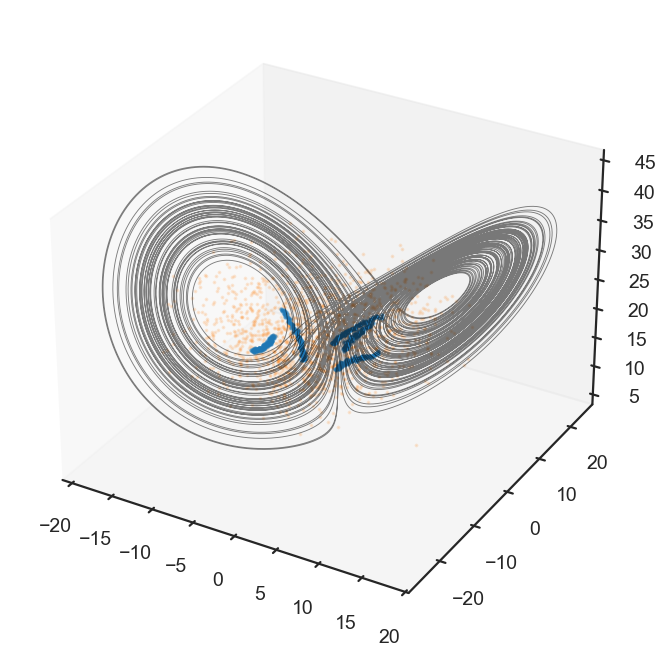

In [6]:
from mfsindy.cases.lorenz_plots import plot_multifidelity_trajectories
X_clean, _, _ = generate_lorenz_dataset(
    n_traj=1,
    T=cfg.T_true,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)
X_hf_batch, t_train, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_clean),
    seed=cfg.seed_base + 5,
)
X_lf_batch, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_clean),
    seed=cfg.seed_base + 125,
)
plot_multifidelity_trajectories(X_hf_batch, X_lf_batch, X_clean)




In [4]:
print(
    f"Running Part 1 Lorenz experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_lorenz_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()/27
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)
print(mae_summary)
print(l0_summary)


Running Part 1 Lorenz experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Lorenz MF: 100%|██████████| 5/5 [01:18<00:00, 15.66s/it]

         median       q25       q75
model                              
HF     0.060310  0.056935  0.061685
LF     0.087781  0.074939  0.101611
MF     0.086150  0.077204  0.096160
MF_w   0.001297  0.000757  0.001749
         median       q25       q75
model                              
HF     0.015873  0.015873  0.021164
LF     0.031746  0.026455  0.031746
MF     0.026455  0.026455  0.031746
MF_w   0.000000  0.000000  0.000000


### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.


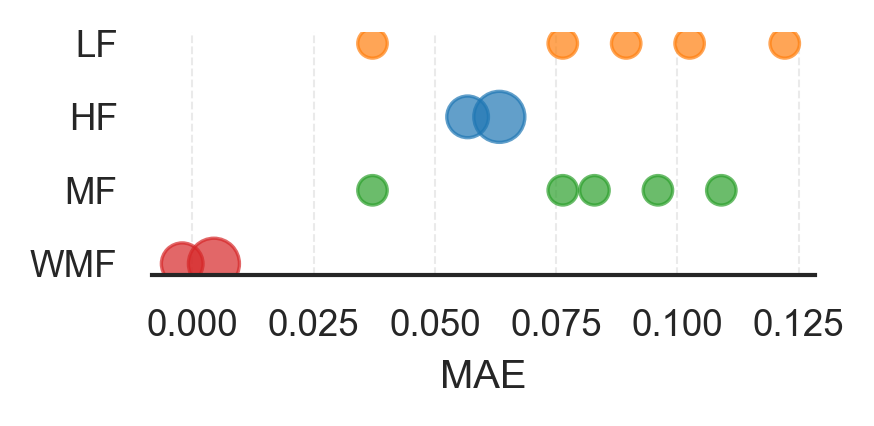

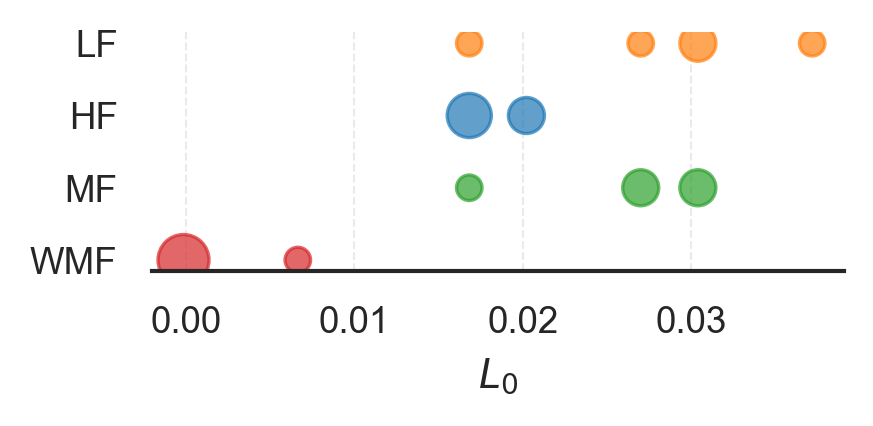

In [7]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

